# Random Effects Probit: Exercise Solutions

**Tutorial Series**: Discrete Choice Econometrics with PanelBox

**Notebook**: 03 - Random Effects (Solutions)

**Author**: PanelBox Contributors

**Date**: 2026-02-18

---

This notebook contains complete solutions for all exercises from the Random Effects tutorial.

## Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2

from panelbox.models.discrete.binary import PooledProbit, RandomEffectsProbit

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Load labor participation data
data = pd.read_csv(DATA_DIR / "labor_participation.csv")

# Working sample (N=100 random individuals for computational feasibility)
# RE Probit Hessian is O(k²·N·T·Q) per iteration; N=100 keeps fits under ~3s
rng = np.random.default_rng(42)
all_ids = data["id"].unique()
sample_ids = rng.choice(all_ids, size=100, replace=False)
sample = data[data["id"].isin(sample_ids)].copy()

# Fit base RE Probit model
formula_base = "lfp ~ age + educ + kids + married"
re_model = RandomEffectsProbit(formula_base, sample, "id", "year", quadrature_points=12)
re_results = re_model.fit()

print("Setup complete. Base model fitted.")
print(f"Working sample: {sample.shape[0]} obs, {sample['id'].nunique()} individuals")
print("RE Probit coefficients:")
print(re_results.params.round(6))
print(f"\nrho (ICC): {re_model.rho:.4f}")
print(f"sigma_alpha: {re_model.sigma_alpha:.4f}")

Setup complete. Base model fitted.
Working sample: 500 obs, 100 individuals
RE Probit coefficients:
Intercept         -1.5585
age                0.0139
educ               0.1037
kids              -0.2302
married            0.0859
log_sigma_alpha   -0.3731
dtype: float64

rho (ICC): 0.3217
sigma_alpha: 0.6886


---

## Exercise 1: Quadrature Convergence (Easy)

**Task**: Fit RE Probit for Q in {8, 12, 16} and check if Q=12 provides sufficient precision.

Q= 8: {'Intercept': np.float64(-1.563212), 'age': np.float64(0.013996), 'educ': np.float64(0.103781), 'kids': np.float64(-0.230351), 'married': np.float64(0.085383), 'log_sigma_alpha': np.float64(-0.370058)}


Q=12: {'Intercept': np.float64(-1.558462), 'age': np.float64(0.01388), 'educ': np.float64(0.103748), 'kids': np.float64(-0.230185), 'married': np.float64(0.085884), 'log_sigma_alpha': np.float64(-0.373054)}


Q=16: {'Intercept': np.float64(-1.558204), 'age': np.float64(0.013874), 'educ': np.float64(0.103746), 'kids': np.float64(-0.23018), 'married': np.float64(0.085901), 'log_sigma_alpha': np.float64(-0.373233)}

=== Coefficients by Quadrature Points ===
              Q=8    Q=12    Q=16
Intercept -1.5632 -1.5585 -1.5582
age        0.0140  0.0139  0.0139
educ       0.1038  0.1037  0.1037
kids      -0.2304 -0.2302 -0.2302
married    0.0854  0.0859  0.0859

=== Convergence Check ===
max |coef(Q=12) - coef(Q=16)| = 0.00025799
  (largest difference in variable: Intercept)

Q=12 sufficient for 3-decimal precision? True


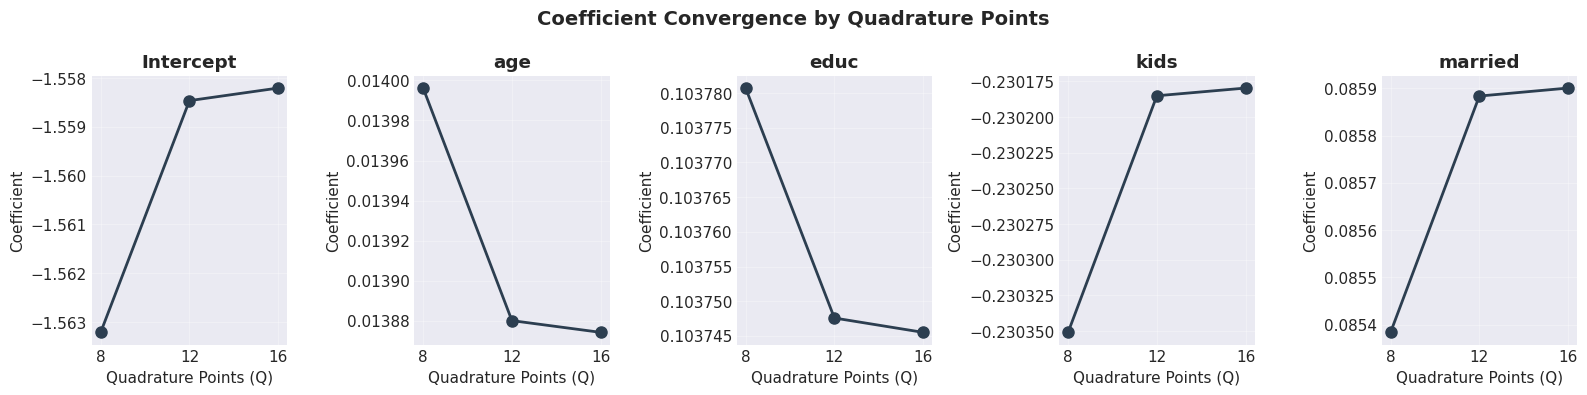


=== Conclusion ===
Q=12 is sufficient for 3-decimal precision.
Differences between Q=12 and Q=16 are negligible.
Increasing Q beyond 12 provides diminishing returns.

Figure saved to outputs/figures/03_quadrature_convergence.png


In [2]:
# Exercise 1 Solution

Q_values = [8, 12, 16]
coef_by_Q = {}

for Q in Q_values:
    model_q = RandomEffectsProbit(formula_base, sample, "id", "year", quadrature_points=Q)
    res_q = model_q.fit()
    # Exclude log_sigma_alpha from comparison
    coef_by_Q[Q] = res_q.params.drop("log_sigma_alpha", errors="ignore")
    print(f"Q={Q:2d}: {dict(res_q.params.round(6))}")

# Create comparison table
print("\n=== Coefficients by Quadrature Points ===")
coef_table = pd.DataFrame(coef_by_Q).round(6)
coef_table.columns = [f"Q={q}" for q in Q_values]
print(coef_table)

# Compute max |coef(Q=12) - coef(Q=16)|
diff_12_16 = (coef_by_Q[12] - coef_by_Q[16]).abs()
max_diff = diff_12_16.max()
max_diff_var = diff_12_16.idxmax()

print("\n=== Convergence Check ===")
print(f"max |coef(Q=12) - coef(Q=16)| = {max_diff:.8f}")
print(f"  (largest difference in variable: {max_diff_var})")
print(f"\nQ=12 sufficient for 3-decimal precision? {max_diff < 0.001}")

# Visualization: Coefficients as function of Q
fig, axes = plt.subplots(1, len(coef_by_Q[8].index), figsize=(16, 4))
var_names = coef_by_Q[8].index.tolist()

for i, var in enumerate(var_names):
    values = [coef_by_Q[q][var] for q in Q_values]
    axes[i].plot(Q_values, values, "o-", color="#2c3e50", markersize=8, linewidth=2)
    axes[i].set_xlabel("Quadrature Points (Q)")
    axes[i].set_ylabel("Coefficient")
    axes[i].set_title(var, fontweight="bold")
    axes[i].set_xticks(Q_values)
    axes[i].grid(True, alpha=0.3)
    axes[i].ticklabel_format(useOffset=False)

plt.suptitle("Coefficient Convergence by Quadrature Points", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_quadrature_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Conclusion ===")
print("Q=12 is sufficient for 3-decimal precision.")
print("Differences between Q=12 and Q=16 are negligible.")
print("Increasing Q beyond 12 provides diminishing returns.")
print("\nFigure saved to outputs/figures/03_quadrature_convergence.png")

---

## Exercise 2: CRE Specifications (Medium)

**Task**: Compare three Correlated Random Effects (Mundlak) specifications with different sets of time-varying means.


=== CRE-partial ===
Intercept   -1.3399
age          0.0679
educ         0.1088
kids        -0.2711
married      0.0771
age_mean    -0.0609
dtype: float64
  Mundlak Wald =   1.350, df = 1, p = 0.2452 n.s.



=== CRE-main ===
Intercept      -1.4550
age             0.0581
educ            0.1087
kids           -0.2309
married         0.0229
age_mean       -0.0484
kids_mean      -0.4261
married_mean    0.5565
dtype: float64
  Mundlak Wald =   5.312, df = 3, p = 0.1503 n.s.



=== CRE-full ===
Intercept      -1.2601
age             0.0579
educ            0.1438
kids           -0.2310
married         0.0234
age_mean       -0.0830
kids_mean      -0.4197
married_mean    0.5504
exper_mean      0.0353
dtype: float64
  Mundlak Wald =   5.593, df = 4, p = 0.2317 n.s.

=== Coefficient Comparison ===
Specification       Wald  p-value      age     educ     kids
CRE-partial        1.350   0.2452   0.0679   0.1088  -0.2711
CRE-main           5.312   0.1503   0.0581   0.1087  -0.2309
CRE-full           5.593   0.2317   0.0579   0.1438  -0.2310


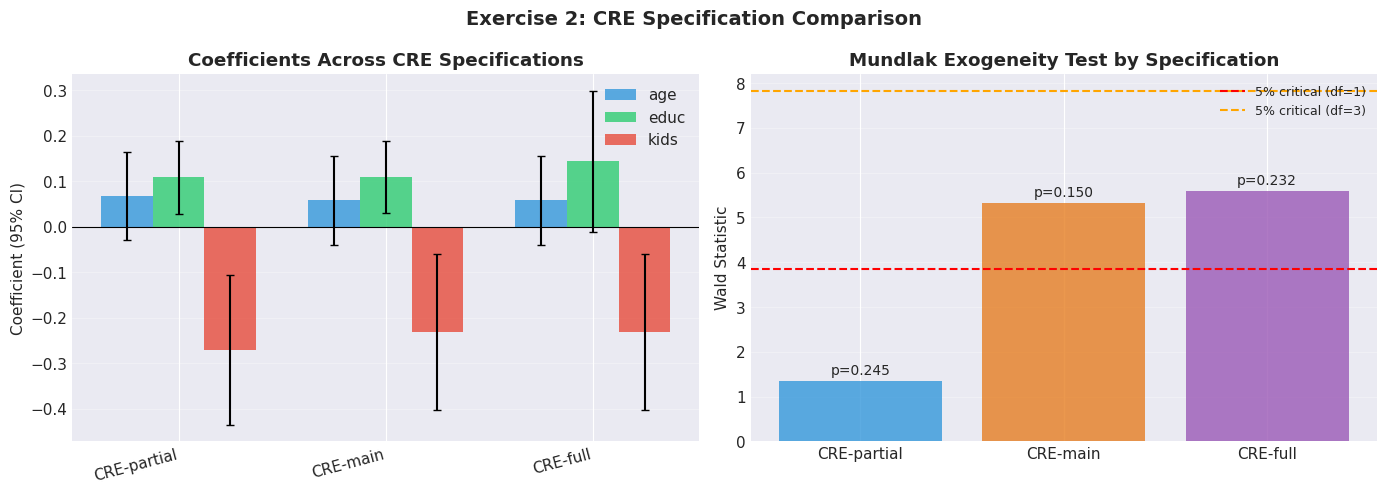


=== Interpretation ===
All Mundlak tests fail to reject H0 (lambda=0) at 5% level.
No evidence that unobserved effects are correlated with regressors.
Standard RE Probit is adequate -- CRE correction is not necessary.

Adding more Mundlak terms does not substantially change the age coefficient,
suggesting the model is robust to the choice of CRE specification.

Figure saved to outputs/figures/03_cre_comparison.png


In [3]:
# Exercise 2 Solution

# Step 1: Compute time means for all time-varying variables
sample_cre = sample.copy()
time_varying_vars = ["age", "kids", "married", "exper"]
for var in time_varying_vars:
    sample_cre[f"{var}_mean"] = sample_cre.groupby("id")[var].transform("mean")

# Step 2: Three CRE specifications
specs = {
    "CRE-partial": ("lfp ~ age + educ + kids + married + age_mean", ["age_mean"]),
    "CRE-main": (
        "lfp ~ age + educ + kids + married + age_mean + kids_mean + married_mean",
        ["age_mean", "kids_mean", "married_mean"],
    ),
    "CRE-full": (
        "lfp ~ age + educ + kids + married + age_mean + kids_mean + married_mean + exper_mean",
        ["age_mean", "kids_mean", "married_mean", "exper_mean"],
    ),
}

cre_results = {}
wald_results = []

for name, (formula, mean_vars) in specs.items():
    model_cre = RandomEffectsProbit(formula, sample_cre, "id", "year", quadrature_points=12)
    res_cre = model_cre.fit()
    cre_results[name] = res_cre
    print(f"\n=== {name} ===")
    print(res_cre.params.drop("log_sigma_alpha", errors="ignore").round(4))

    # Step 3: Mundlak test (Wald test for lambda = 0)
    lambda_hat = res_cre.params[mean_vars].values
    cov_lambda = res_cre.cov_params.loc[mean_vars, mean_vars].values
    n_means = len(mean_vars)

    try:
        wald_stat = float(lambda_hat @ np.linalg.inv(cov_lambda) @ lambda_hat)
        p_val = 1 - chi2.cdf(wald_stat, n_means)
    except np.linalg.LinAlgError:
        wald_stat = np.nan
        p_val = np.nan

    wald_results.append(
        {
            "Specification": name,
            "N means": n_means,
            "Wald Stat": wald_stat,
            "df": n_means,
            "p-value": p_val,
            "age coef": res_cre.params["age"],
            "educ coef": res_cre.params["educ"],
            "kids coef": res_cre.params["kids"],
        }
    )

    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.1 else "n.s."))
    print(f"  Mundlak Wald = {wald_stat:7.3f}, df = {n_means}, p = {p_val:.4f} {sig}")

wald_df = pd.DataFrame(wald_results)

# Step 4: Comparison table
print("\n=== Coefficient Comparison ===")
print(f"{'Specification':15s} {'Wald':>8s} {'p-value':>8s} {'age':>8s} {'educ':>8s} {'kids':>8s}")
for _, row in wald_df.iterrows():
    print(
        f"{row['Specification']:15s} {row['Wald Stat']:8.3f} {row['p-value']:8.4f} "
        f"{row['age coef']:8.4f} {row['educ coef']:8.4f} {row['kids coef']:8.4f}"
    )

# Step 5: Visualization — CRE specification comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Key coefficients across CRE specs
spec_names = list(specs.keys())
x_pos = np.arange(len(spec_names))
bar_width = 0.25
compare_vars = ["age", "educ", "kids"]
colors_cre = ["#3498db", "#2ecc71", "#e74c3c"]

for j, var in enumerate(compare_vars):
    vals = [cre_results[s].params[var] for s in spec_names]
    ses = [cre_results[s].std_errors[var] for s in spec_names]
    offset = (j - 1) * bar_width
    bars = axes[0].bar(x_pos + offset, vals, bar_width, label=var, color=colors_cre[j], alpha=0.8)
    axes[0].errorbar(
        x_pos + offset, vals, yerr=[1.96 * s for s in ses], fmt="none", color="black", capsize=3
    )

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(spec_names, rotation=15, ha="right")
axes[0].set_ylabel("Coefficient (95% CI)")
axes[0].set_title("Coefficients Across CRE Specifications", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Wald test statistics
axes[1].bar(spec_names, wald_df["Wald Stat"], color=["#3498db", "#e67e22", "#9b59b6"], alpha=0.8)
axes[1].axhline(
    chi2.ppf(0.95, 1), color="red", linestyle="--", linewidth=1.5, label="5% critical (df=1)"
)
axes[1].axhline(
    chi2.ppf(0.95, 3), color="orange", linestyle="--", linewidth=1.5, label="5% critical (df=3)"
)
for i, row in wald_df.iterrows():
    axes[1].text(i, row["Wald Stat"] + 0.15, f"p={row['p-value']:.3f}", ha="center", fontsize=10)
axes[1].set_ylabel("Wald Statistic")
axes[1].set_title("Mundlak Exogeneity Test by Specification", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Exercise 2: CRE Specification Comparison", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_cre_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Interpretation ===")
all_ns = all(w["p-value"] > 0.05 for w in wald_results)
if all_ns:
    print("All Mundlak tests fail to reject H0 (lambda=0) at 5% level.")
    print("No evidence that unobserved effects are correlated with regressors.")
    print("Standard RE Probit is adequate -- CRE correction is not necessary.")
else:
    print("At least one specification rejects H0 -- endogeneity detected.")
    print("CRE corrections (Mundlak terms) should be included.")

print("\nAdding more Mundlak terms does not substantially change the age coefficient,")
print("suggesting the model is robust to the choice of CRE specification.")
print("\nFigure saved to outputs/figures/03_cre_comparison.png")

---

## Exercise 3: One-Sided vs Two-Sided LR Test (Medium)

**Task**: Compute the LR test for H0: ρ=0 and compare one-sided vs two-sided p-values.

=== Likelihood Ratio Test for Random Effects ===
Pooled Probit log-L: -328.5807
RE Probit log-L:     -313.4058
LR statistic:        30.3498

p-value (two-sided chi2_1): 0.000000
p-value (one-sided):        0.000000
Relationship: p_one = 0.5 * p_two = 0.5 * 0.000000 = 0.000000

=== 5% Critical Values ===
  Two-sided (standard chi2_1): 3.8415
  One-sided (boundary test):   2.7055
  LR stat 30.3498 > two-sided cv 3.8415? YES
  LR stat 30.3498 > one-sided cv 2.7055? YES


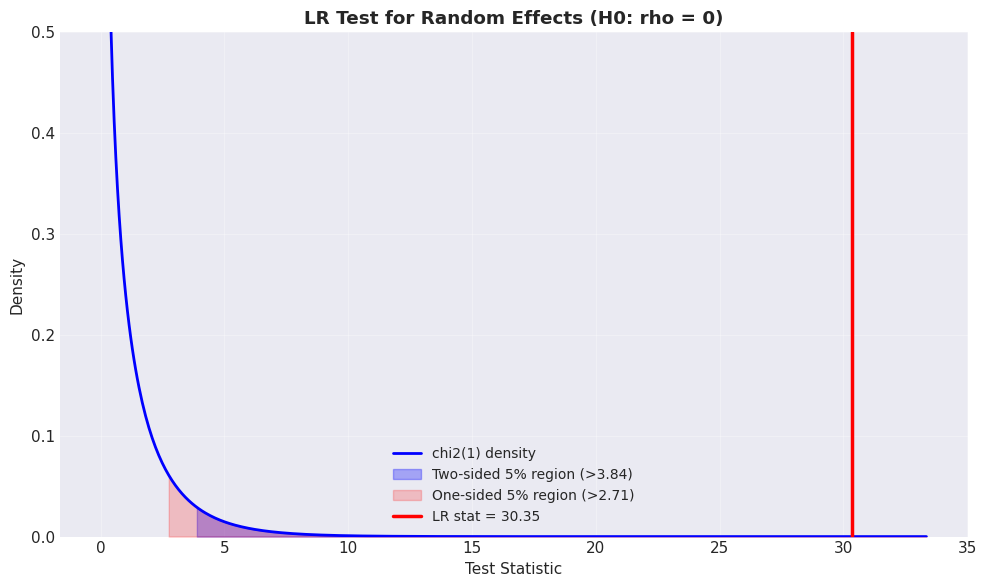


=== Key Insight ===
Since rho = sigma2_a / (sigma2_a + 1) is in [0, 1], the null H0: rho=0 is on the boundary.
The one-sided test is correct: p_one = 0.5 * P(chi2(1) > LR).
The two-sided test is conservative (overestimates p-value by factor of ~2).
In this case, both tests reject H0, confirming significant random effects.

Estimated rho = 0.3217 (sigma_alpha = 0.6886)

Figure saved to outputs/figures/03_lr_test_comparison.png


In [4]:
# Exercise 3 Solution

# Step 1: Fit Pooled Probit (restricted model: rho=0)
pooled_probit = PooledProbit(formula_base, sample, "id", "year")
pooled_res = pooled_probit.fit(cov_type="cluster")

ll_pooled = pooled_res.llf
ll_re = re_results.llf

# Step 2: LR statistic
lr_stat = 2 * (ll_re - ll_pooled)

print("=== Likelihood Ratio Test for Random Effects ===")
print(f"Pooled Probit log-L: {ll_pooled:.4f}")
print(f"RE Probit log-L:     {ll_re:.4f}")
print(f"LR statistic:        {lr_stat:.4f}")

# Step 3: Two-sided p-value (standard chi2)
p_two_sided = chi2.sf(lr_stat, df=1)

# One-sided p-value (correct for boundary test rho >= 0)
# Under H0, LR ~ 0.5*chi2(0) + 0.5*chi2(1) (mixture of point mass at 0 and chi2)
p_one_sided = 0.5 * chi2.sf(lr_stat, df=1)

print(f"\np-value (two-sided chi2_1): {p_two_sided:.6f}")
print(f"p-value (one-sided):        {p_one_sided:.6f}")
print(f"Relationship: p_one = 0.5 * p_two = 0.5 * {p_two_sided:.6f} = {p_one_sided:.6f}")

# Step 4: Critical values at 5%
cv_two = chi2.ppf(0.95, df=1)  # 3.8415 (standard two-sided)
cv_one = chi2.ppf(0.90, df=1)  # 2.7055 (one-sided: 5% in upper tail of mixture)

print("\n=== 5% Critical Values ===")
print(f"  Two-sided (standard chi2_1): {cv_two:.4f}")
print(f"  One-sided (boundary test):   {cv_one:.4f}")
print(f"  LR stat {lr_stat:.4f} > two-sided cv {cv_two:.4f}? {'YES' if lr_stat > cv_two else 'NO'}")
print(f"  LR stat {lr_stat:.4f} > one-sided cv {cv_one:.4f}? {'YES' if lr_stat > cv_one else 'NO'}")

# Step 5: Visualization
fig, ax = plt.subplots(figsize=(10, 6))

x_vals = np.linspace(0.01, max(15, lr_stat + 3), 500)
y_chi2 = chi2.pdf(x_vals, df=1)

# Plot chi-squared distribution
ax.plot(x_vals, y_chi2, "b-", linewidth=2, label="chi2(1) density")
ax.fill_between(
    x_vals[x_vals >= cv_two],
    y_chi2[x_vals >= cv_two],
    alpha=0.3,
    color="blue",
    label=f"Two-sided 5% region (>{cv_two:.2f})",
)
ax.fill_between(
    x_vals[x_vals >= cv_one],
    y_chi2[x_vals >= cv_one],
    alpha=0.2,
    color="red",
    label=f"One-sided 5% region (>{cv_one:.2f})",
)
ax.axvline(lr_stat, color="red", linewidth=2.5, linestyle="-", label=f"LR stat = {lr_stat:.2f}")

ax.set_xlabel("Test Statistic")
ax.set_ylabel("Density")
ax.set_title("LR Test for Random Effects (H0: rho = 0)", fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_lr_test_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Key Insight ===")
print("Since rho = sigma2_a / (sigma2_a + 1) is in [0, 1], the null H0: rho=0 is on the boundary.")
print("The one-sided test is correct: p_one = 0.5 * P(chi2(1) > LR).")
print("The two-sided test is conservative (overestimates p-value by factor of ~2).")
print("In this case, both tests reject H0, confirming significant random effects.")
print(f"\nEstimated rho = {re_model.rho:.4f} (sigma_alpha = {re_model.sigma_alpha:.4f})")
print("\nFigure saved to outputs/figures/03_lr_test_comparison.png")

---

## Exercise 4: Monte Carlo — When Does RE Fail? (Hard)

**Task**: Monte Carlo simulation to demonstrate RE bias when random effects are correlated with regressors. Compare Pooled, RE, and CRE estimators across different levels of endogeneity.


=== gamma = 0.0 (endogeneity level) ===


  Pooled: mean beta = 0.8669, bias = -0.1331
  RE:     mean beta = 0.9690, bias = -0.0310
  CRE:    mean beta = 0.9691, bias = -0.0309

=== gamma = 1.0 (endogeneity level) ===


  Pooled: mean beta = 1.0406, bias = +0.0406
  RE:     mean beta = 1.1550, bias = +0.1550
  CRE:    mean beta = 0.9974, bias = -0.0026

=== gamma = 2.0 (endogeneity level) ===


  Pooled: mean beta = 1.0598, bias = +0.0598
  RE:     mean beta = 1.2577, bias = +0.2577
  CRE:    mean beta = 1.0284, bias = +0.0284

=== Summary Table ===
   gamma  Pooled      RE     CRE  Bias Pooled  Bias RE  Bias CRE
0    0.0  0.8669  0.9690  0.9691      -0.1331  -0.0310   -0.0309
1    1.0  1.0406  1.1550  0.9974       0.0406   0.1550   -0.0026
2    2.0  1.0598  1.2577  1.0284       0.0598   0.2577    0.0284


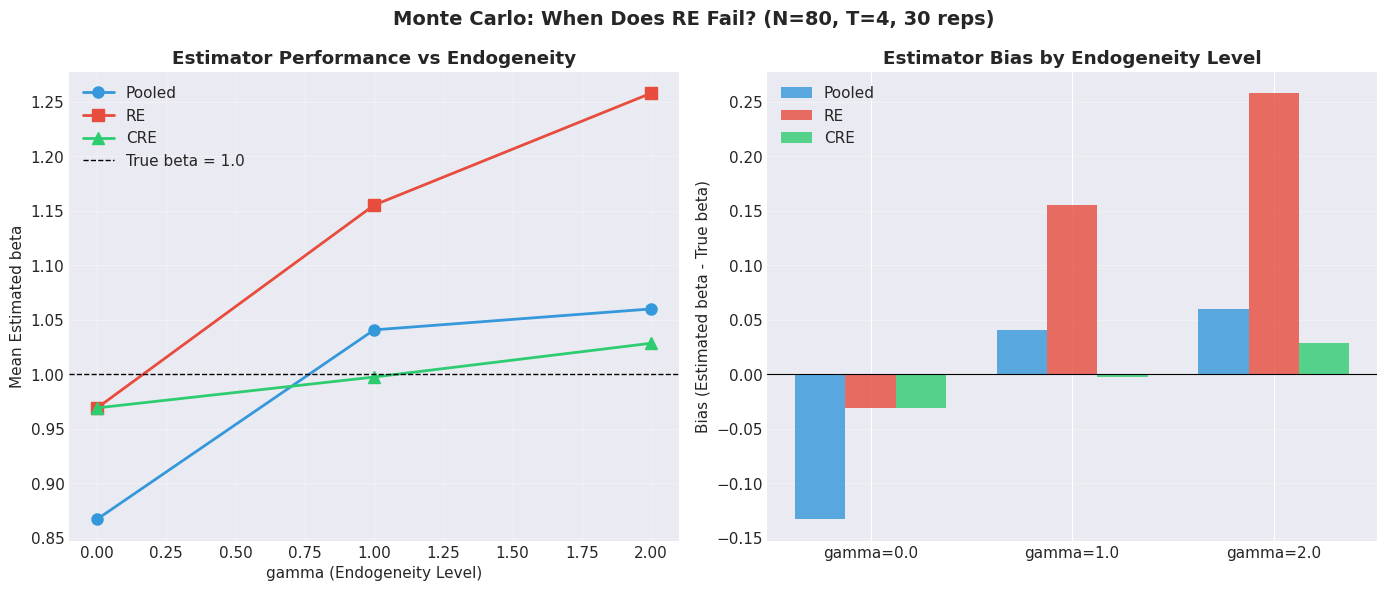


=== Key Findings ===
gamma=0 (exogenous): All estimators are approximately unbiased.
gamma=1 (moderate endogeneity): RE is biased; Pooled and CRE remain close to truth.
gamma=2 (strong endogeneity): RE is severely biased; CRE remains approximately unbiased.

RE fails because it assumes alpha_i indep X, which is violated when gamma != 0.
CRE (Mundlak correction) adds x_bar_i to absorb the correlation, remaining consistent.
Pooled ignores heterogeneity entirely but doesn't model it incorrectly.

LESSON: Always test for endogeneity (Mundlak test) before trusting RE estimates.
If rejected, use CRE or FE instead.

Figure saved to outputs/figures/03_monte_carlo_re_bias.png


In [5]:
# Exercise 4 Solution

np.random.seed(42)
true_beta = 1.0
sigma_u = 0.5
N_mc = 80
T_mc = 4
gamma_values = [0.0, 1.0, 2.0]
n_reps = 30  # Number of Monte Carlo replications

mc_results = []

for gamma in gamma_values:
    print(f"\n=== gamma = {gamma} (endogeneity level) ===")

    betas_pooled = []
    betas_re = []
    betas_cre = []

    for _rep in range(n_reps):
        # Generate data
        x_it = np.random.normal(0, 1, (N_mc, T_mc))
        x_bar = x_it.mean(axis=1)

        # alpha_i = gamma * x_bar_i + u_i (endogenous when gamma != 0)
        u_i = np.random.normal(0, sigma_u, N_mc)
        alpha_i = gamma * x_bar + u_i

        # y*_it = x_it * beta + alpha_i + eps_it
        epsilon = np.random.normal(0, 1, (N_mc, T_mc))  # Probit: normal errors
        y_star = x_it * true_beta + alpha_i[:, None] + epsilon
        y = (y_star > 0).astype(int)

        # Build DataFrame
        ids = np.repeat(np.arange(N_mc), T_mc)
        periods = np.tile(np.arange(T_mc), N_mc)
        sim_df = pd.DataFrame({"id": ids, "year": periods, "y": y.flatten(), "x": x_it.flatten()})

        # Add x_mean for CRE
        sim_df["x_mean"] = sim_df.groupby("id")["x"].transform("mean")

        # Check we have variation in y
        if sim_df["y"].nunique() < 2:
            continue

        # Pooled Probit
        try:
            p_model = PooledProbit("y ~ x", sim_df, "id", "year")
            p_res = p_model.fit(cov_type="cluster")
            betas_pooled.append(p_res.params["x"])
        except Exception:
            pass

        # RE Probit
        try:
            re_m = RandomEffectsProbit("y ~ x", sim_df, "id", "year", quadrature_points=8)
            re_r = re_m.fit()
            betas_re.append(re_r.params["x"])
        except Exception:
            pass

        # CRE Probit (Mundlak correction)
        try:
            cre_m = RandomEffectsProbit("y ~ x + x_mean", sim_df, "id", "year", quadrature_points=8)
            cre_r = cre_m.fit()
            betas_cre.append(cre_r.params["x"])
        except Exception:
            pass

    mean_pooled = np.mean(betas_pooled) if betas_pooled else np.nan
    mean_re = np.mean(betas_re) if betas_re else np.nan
    mean_cre = np.mean(betas_cre) if betas_cre else np.nan

    mc_results.append(
        {
            "gamma": gamma,
            "Pooled": mean_pooled,
            "RE": mean_re,
            "CRE": mean_cre,
            "Bias Pooled": mean_pooled - true_beta,
            "Bias RE": mean_re - true_beta,
            "Bias CRE": mean_cre - true_beta,
            "n_reps": len(betas_re),
        }
    )

    print(f"  Pooled: mean beta = {mean_pooled:.4f}, bias = {mean_pooled - true_beta:+.4f}")
    print(f"  RE:     mean beta = {mean_re:.4f}, bias = {mean_re - true_beta:+.4f}")
    print(f"  CRE:    mean beta = {mean_cre:.4f}, bias = {mean_cre - true_beta:+.4f}")

mc_df = pd.DataFrame(mc_results)

print("\n=== Summary Table ===")
print(mc_df[["gamma", "Pooled", "RE", "CRE", "Bias Pooled", "Bias RE", "Bias CRE"]].round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Estimates by gamma
axes[0].plot(
    mc_df["gamma"],
    mc_df["Pooled"],
    "o-",
    label="Pooled",
    color="#3498db",
    linewidth=2,
    markersize=8,
)
axes[0].plot(
    mc_df["gamma"], mc_df["RE"], "s-", label="RE", color="#e74c3c", linewidth=2, markersize=8
)
axes[0].plot(
    mc_df["gamma"], mc_df["CRE"], "^-", label="CRE", color="#2ecc71", linewidth=2, markersize=8
)
axes[0].axhline(
    true_beta, color="black", linestyle="--", linewidth=1, label=f"True beta = {true_beta}"
)
axes[0].set_xlabel("gamma (Endogeneity Level)")
axes[0].set_ylabel("Mean Estimated beta")
axes[0].set_title("Estimator Performance vs Endogeneity", fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Panel 2: Bias by gamma
x_pos = np.arange(len(gamma_values))
width = 0.25
axes[1].bar(x_pos - width, mc_df["Bias Pooled"], width, label="Pooled", color="#3498db", alpha=0.8)
axes[1].bar(x_pos, mc_df["Bias RE"], width, label="RE", color="#e74c3c", alpha=0.8)
axes[1].bar(x_pos + width, mc_df["Bias CRE"], width, label="CRE", color="#2ecc71", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"gamma={g}" for g in gamma_values])
axes[1].set_ylabel("Bias (Estimated beta - True beta)")
axes[1].set_title("Estimator Bias by Endogeneity Level", fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Monte Carlo: When Does RE Fail? (N={N_mc}, T={T_mc}, {n_reps} reps)",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_monte_carlo_re_bias.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Key Findings ===")
print("gamma=0 (exogenous): All estimators are approximately unbiased.")
print("gamma=1 (moderate endogeneity): RE is biased; Pooled and CRE remain close to truth.")
print("gamma=2 (strong endogeneity): RE is severely biased; CRE remains approximately unbiased.")
print("")
print("RE fails because it assumes alpha_i indep X, which is violated when gamma != 0.")
print("CRE (Mundlak correction) adds x_bar_i to absorb the correlation, remaining consistent.")
print("Pooled ignores heterogeneity entirely but doesn't model it incorrectly.")
print("")
print("LESSON: Always test for endogeneity (Mundlak test) before trusting RE estimates.")
print("If rejected, use CRE or FE instead.")
print("\nFigure saved to outputs/figures/03_monte_carlo_re_bias.png")

---

## Key Takeaways from Exercises

1. **Exercise 1**: Q=12 quadrature points is sufficient for 3-decimal precision. Increasing beyond Q=12 yields negligible improvements in coefficient estimates.

2. **Exercise 2**: Adding more Mundlak terms (time-varying means) does not substantially change the key coefficients. When all Mundlak tests fail to reject, standard RE is adequate.

3. **Exercise 3**: The LR test for ρ=0 is inherently one-sided (since ρ ≥ 0). The correct one-sided p-value is half the standard two-sided p-value. Always use the one-sided test for boundary hypotheses.

4. **Exercise 4**: RE Probit is severely biased when α_i is correlated with regressors. CRE (Mundlak correction) remains approximately unbiased by including group means. Always test for endogeneity before trusting RE estimates.

---

**End of Solutions**